# Adult Income Dataset — Machine Learning Project
## Built-in Library vs From Scratch Implementation

**Dataset:** Adult Census Income (48,842 records × 15 features)  
**Target:** Predict whether income is >50K or <=50K  
**Models Covered:**
1. Decision Tree
2. Random Forest
3. Linear Regression
4. Logistic Regression
5. KNN
6. Naive Bayes

---

## Step 0 — Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report,
    
)

---
## (EDA)

In [3]:
df = pd.read_csv('/content/adult.csv')
print('Shape:', df.shape)
df.head()

Shape: (48842, 15)


,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   age              48842 non-null  int64 
 1   workclass        48842 non-null  object
 2   fnlwgt           48842 non-null  int64 
 3   education        48842 non-null  object
 4   educational-num  48842 non-null  int64 
 5   marital-status   48842 non-null  object
 6   occupation       48842 non-null  object
 7   relationship     48842 non-null  object
 8   race             48842 non-null  object
 9   gender           48842 non-null  object
 10  capital-gain     48842 non-null  int64 
 11  capital-loss     48842 non-null  int64 
 12  hours-per-week   48842 non-null  int64 
 13  native-country   48842 non-null  object
 14  income           48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


In [5]:
df.describe()

,age,fnlwgt,educational-num,capital-gain,capital-loss,hours-per-week
count,48842.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,1.896641e+05,10.078089,1079.067626,87.502314,40.422382
std,13.710510,1.056040e+05,2.570973,7452.019058,403.004552,12.391444
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


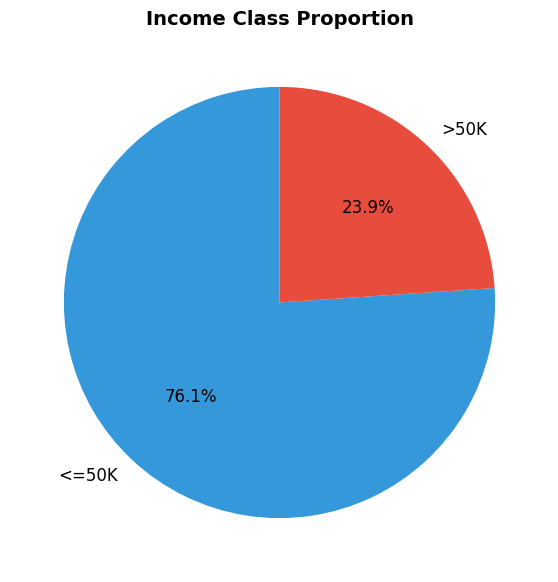

In [6]:
counts = df['income'].value_counts()
colors = ['#3498db', '#e74c3c']

plt.figure(figsize=(7, 7))
plt.pie(
    counts.values,
    labels=counts.index,
    colors=colors,
    autopct='%1.1f%%',
    startangle=90,
    textprops={'fontsize': 12}
)
plt.title('Income Class Proportion', fontsize=14, fontweight='bold')
plt.show()

---
## Step 2 — Data Cleaning & Preprocessing (Global)

- Replace “?” with the Mode
- Remove Redundant Columns
- Encode the Target Variable

In [7]:
print(' Hidden Missing Values ("?"):')
for col in df.select_dtypes(include='object').columns:
   count = (df[col] == '?').sum()
   if count > 0:
     print(f' {col}: {count}')

 Hidden Missing Values ("?"):
 workclass: 2799
 occupation: 2809
 native-country: 857


In [8]:
df_clean = df.copy()

# Replace '?' with mode
cols_with_question = ['workclass', 'occupation', 'native-country']
for col in cols_with_question:
    mode_val = df_clean[col][df_clean[col] != '?'].mode()[0]
    before = (df_clean[col] == '?').sum()
    df_clean[col] = df_clean[col].replace('?', mode_val)
    print(f' {col}: replaced {before} "?" with mode → "{mode_val}"')

#Drop redundant columns
df_clean.drop(columns=['education', 'fnlwgt'], inplace=True)

#Encode target variable
df_clean['income'] = df_clean['income'].map({'<=50K': 0, '>50K': 1})

df_clean.head()

 workclass: replaced 2799 "?" with mode → "Private"
 occupation: replaced 2809 "?" with mode → "Prof-specialty"
 native-country: replaced 857 "?" with mode → "United-States"


,age,workclass,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,0
1,38,Private,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,0
2,28,Local-gov,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,1
3,44,Private,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,1
4,18,Private,10,Never-married,Prof-specialty,Own-child,White,Female,0,0,30,United-States,0


In [9]:
X_raw = df_clean.drop('income', axis=1)
y = df_clean['income'].values

cat_features = X_raw.select_dtypes(include='object').columns.tolist()
num_features = X_raw.select_dtypes(include=['int64', 'float64']).columns.tolist()

print(' Numerical features:', num_features)
print(' Categorical features:', cat_features)

 Numerical features: ['age', 'educational-num', 'capital-gain', 'capital-loss', 'hours-per-week']
 Categorical features: ['workclass', 'marital-status', 'occupation', 'relationship', 'race', 'gender', 'native-country']


---
## Step 3 — Model-Specific Preprocessing

| الموديل | Encoding | Scaling |
|---------|----------|---------|
| Decision Tree | Label Encoding |  NO |
| Random Forest | Label Encoding | NO|
| Linear Regression | One-Hot Encoding | StandardScaler |
| Logistic Regression | One-Hot Encoding | StandardScaler |
| KNN | One-Hot Encoding | MinMaxScaler |
| Naïve Bayes | Label Encoding | NO|

In [10]:
# Dataset A: Label Encoded for --> (Decision Tree +Random Forest +Naive Bayes)
X_le = X_raw.copy()
le_encoders = {}
for col in cat_features:
    le = LabelEncoder()
    X_le[col] = le.fit_transform(X_le[col])
    le_encoders[col] = le
X_le = X_le.values  # numpy array
print('Dataset A (Label Encoded) shape:', X_le.shape)


# Dataset B: One-Hot Encoded + StandardScaler for --> Logistic + Linear Reg
X_ohe = pd.get_dummies(X_raw, columns=cat_features, drop_first=True)
scaler_std = StandardScaler()
X_ohe_std = scaler_std.fit_transform(X_ohe)
print('Dataset B (OHE + StandardScaler) shape:', X_ohe_std.shape)


# Dataset C: One-Hot Encoded + MinMaxScaler for (KNN)
scaler_mm = MinMaxScaler()
X_ohe_mm = scaler_mm.fit_transform(X_ohe)
print('Dataset C (OHE + MinMaxScaler) shape:', X_ohe_mm.shape)

Dataset A (Label Encoded) shape: (48842, 12)
Dataset B (OHE + StandardScaler) shape: (48842, 81)
Dataset C (OHE + MinMaxScaler) shape: (48842, 81)


In [11]:
# Train/Test Splits for each dataset
RANDOM_STATE = 42
TEST_SIZE    = 0.2

# A —(Decision Tree, Random Forest, Naive Bayes)
X_A_train, X_A_test, y_train, y_test = train_test_split(
    X_le, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y)

# B — (Logistic Regression, Linear Regression)
X_B_train, X_B_test, _, _ = train_test_split(
    X_ohe_std, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y)

# C — (KNN)
X_C_train, X_C_test, _, _ = train_test_split(
    X_ohe_mm, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y)

print(f'Training set size: {len(y_train):,}')
print(f'Test set size:     {len(y_test):,}')
print(f'Train class balance: {np.bincount(y_train)}')
print(f'Test  class balance: {np.bincount(y_test)}')

Training set size: 39,073
Test set size:     9,769
Train class balance: [29724  9349]
Test  class balance: [7431 2338]


---
## 📏 Step 4 — Evaluation Helper Function

In [12]:
results_all = {}

def evaluate_model(name, y_true, y_pred, show_report=True):
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    f1   = f1_score(y_true, y_pred, zero_division=0)
    cm   = confusion_matrix(y_true, y_pred)

    print(f'  Accuracy  : {acc:.4f}')
    print(f'  Precision : {prec:.4f}')
    print(f'  Recall    : {rec:.4f}')
    print(f'  F1-Score  : {f1:.4f}')

    if show_report:
        print(f'\n  Classification Report:\n'
              f'{classification_report(y_true, y_pred, target_names=["<=50K",">50K"])}')

    # Confusion Matrix plot
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['<=50K', '>50K'], yticklabels=['<=50K', '>50K'])
    ax.set_title(f'Confusion Matrix — {name}', fontweight='bold')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')
    plt.tight_layout()
    plt.show()

    results_all[name] = {
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1': f1
    }

    return acc, prec, rec, f1

print('Evaluation function ready.')

Evaluation function ready.


---
# MODEL 1 — Decision Tree

**Preprocessing used:** Label Encoding -- no scaling

  Accuracy  : 0.8594
  Precision : 0.7217
  Recall    : 0.6711
  F1-Score  : 0.6955

  Classification Report:
              precision    recall  f1-score   support

       <=50K       0.90      0.92      0.91      7431
        >50K       0.72      0.67      0.70      2338

    accuracy                           0.86      9769
   macro avg       0.81      0.79      0.80      9769
weighted avg       0.86      0.86      0.86      9769



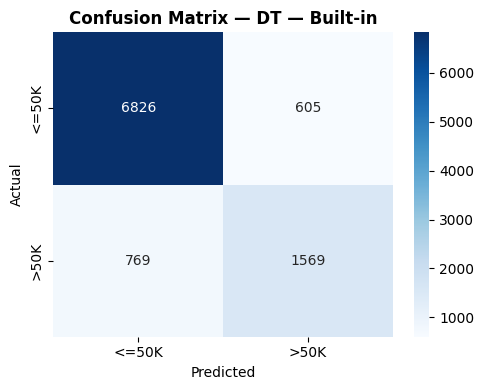

(0.8593510082915344,
 0.7217111315547378,
 0.6710863986313088,
 0.6954787234042553)

In [13]:
#  DECISION TREE — BUILT-IN (sklearn)
dt_builtin = DecisionTreeClassifier(max_depth=10, random_state=RANDOM_STATE, criterion='gini')
dt_builtin.fit(X_A_train, y_train)
dt_pred = dt_builtin.predict(X_A_test)

evaluate_model('DT — Built-in', y_test, dt_pred)

  Accuracy  : 0.8396
  Precision : 0.6707
  Recall    : 0.6480
  F1-Score  : 0.6591

  Classification Report:
              precision    recall  f1-score   support

       <=50K       0.89      0.90      0.90      7431
        >50K       0.67      0.65      0.66      2338

    accuracy                           0.84      9769
   macro avg       0.78      0.77      0.78      9769
weighted avg       0.84      0.84      0.84      9769



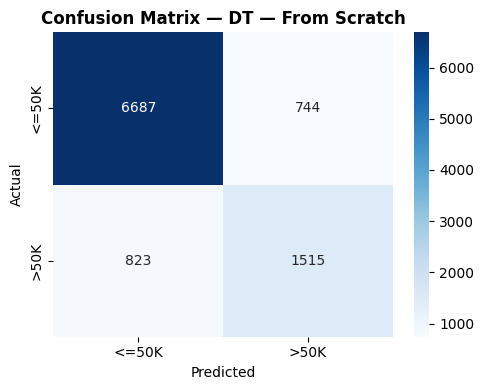

(0.839594636093766, 0.6706507304116865, 0.6479897348160821, 0.6591255166412878)

In [14]:
# DECISION TREE — FROM SCRATCH (No Proba)

class DecisionTreeScratch:
    """
    Binary Decision Tree using Gini impurity.
    """
    def __init__(self, max_depth=10, min_samples_split=2):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.tree = None

    def _gini(self, y):
      #Gini impurity for array y.
        n = len(y)
        if n == 0: return 0
        classes, counts = np.unique(y, return_counts=True)
        probs = counts / n
        return 1 - np.sum(probs ** 2)

    def _best_split(self, X, y):
        """Find the best (feature, threshold) split."""
        best_gini = float('inf')
        best_feat, best_thresh = None, None
        n = len(y)

        for feat in range(X.shape[1]):
            thresholds = np.unique(X[:, feat])
            if len(thresholds) > 20:
                thresholds = np.percentile(X[:, feat], np.linspace(5, 95, 20))

            for thresh in thresholds:
                left_mask  = X[:, feat] <= thresh
                right_mask = ~left_mask
                if left_mask.sum() == 0 or right_mask.sum() == 0:
                    continue
                g = (left_mask.sum() / n)  * self._gini(y[left_mask]) + \
                    (right_mask.sum() / n) * self._gini(y[right_mask])
                if g < best_gini:
                    best_gini  = g
                    best_feat  = feat
                    best_thresh = thresh
        return best_feat, best_thresh

    def _build(self, X, y, depth):
        """Recursively build the tree."""
        # Stopping conditions
        if depth >= self.max_depth or len(y) < self.min_samples_split or len(np.unique(y)) == 1:
            vals, cnts = np.unique(y, return_counts=True)
            return {'leaf': True, 'class': vals[np.argmax(cnts)]}

        feat, thresh = self._best_split(X, y)
        if feat is None:
            vals, cnts = np.unique(y, return_counts=True)
            return {'leaf': True, 'class': vals[np.argmax(cnts)]}

        mask = X[:, feat] <= thresh
        return {
            'leaf': False, 'feat': feat, 'thresh': thresh,
            'left':  self._build(X[mask],  y[mask],  depth + 1),
            'right': self._build(X[~mask], y[~mask], depth + 1)
        }

    def fit(self, X, y):
        self.tree = self._build(X, y, depth=0)
        return self

    def _predict_one(self, x, node):
        if node['leaf']: return node['class']
        if x[node['feat']] <= node['thresh']:
            return self._predict_one(x, node['left'])
        return self._predict_one(x, node['right'])

    def predict(self, X):
        return np.array([self._predict_one(x, self.tree) for x in X])

# Train using subset
SCRATCH_N = 5000
idx = np.random.RandomState(42).choice(len(X_A_train), SCRATCH_N, replace=False)
X_train_s, y_train_s = X_A_train[idx], y_train[idx]

dt_scratch = DecisionTreeScratch(max_depth=10)
dt_scratch.fit(X_train_s, y_train_s)
dt_scratch_pred = dt_scratch.predict(X_A_test)

evaluate_model('DT — From Scratch', y_test, dt_scratch_pred)

---
# MODEL 2 — Random Forest

**Preprocessing used:** Label Encoding -- no scaling needed

  Accuracy  : 0.8654
  Precision : 0.8018
  Recall    : 0.5813
  F1-Score  : 0.6739

  Classification Report:
              precision    recall  f1-score   support

       <=50K       0.88      0.95      0.92      7431
        >50K       0.80      0.58      0.67      2338

    accuracy                           0.87      9769
   macro avg       0.84      0.77      0.79      9769
weighted avg       0.86      0.87      0.86      9769



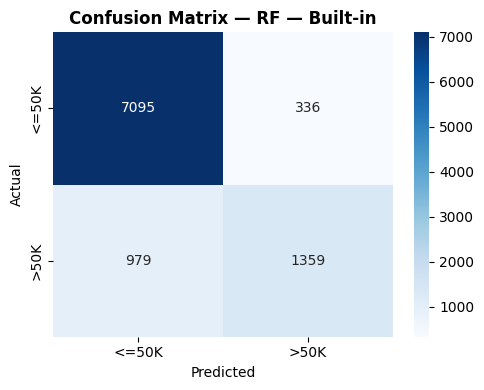

(0.86539052103593, 0.8017699115044248, 0.5812660393498716, 0.6739399950409125)

In [15]:
#  RANDOM FOREST — BUILT-IN (sklearn)
rf_builtin = RandomForestClassifier(n_estimators=100, max_depth=12,
                                     random_state=RANDOM_STATE, n_jobs=-1)

rf_builtin.fit(X_A_train, y_train)
rf_pred = rf_builtin.predict(X_A_test)

evaluate_model('RF — Built-in', y_test, rf_pred)

  Accuracy  : 0.2393
  Precision : 0.2393
  Recall    : 1.0000
  F1-Score  : 0.3862

  Classification Report:
              precision    recall  f1-score   support

       <=50K       0.00      0.00      0.00      7431
        >50K       0.24      1.00      0.39      2338

    accuracy                           0.24      9769
   macro avg       0.12      0.50      0.19      9769
weighted avg       0.06      0.24      0.09      9769



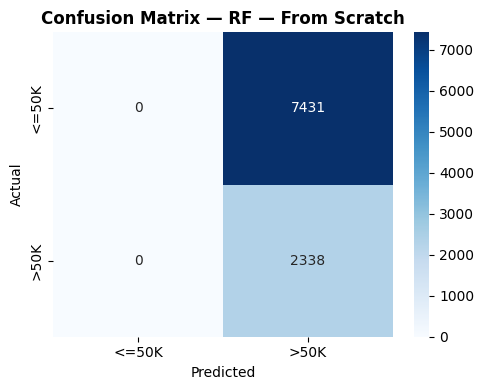

(0.23932848807452145, 0.23932848807452145, 1.0, 0.3862228462872718)

In [16]:
#  RANDOM FOREST — FROM SCRATCH
class RandomForestScratch:
    """
    Random Forest: Bagging of Decision Trees with feature randomness.
    """
    def __init__(self, n_estimators=100, max_depth=12, max_features='sqrt',
                 min_samples_split=2, random_state=42):
        self.n_estimators    = n_estimators
        self.max_depth       = max_depth
        self.max_features    = max_features
        self.min_samples_split = min_samples_split
        self.random_state    = random_state
        self.trees           = []
        self.feature_indices = []

    def _gini(self, y):
        n = len(y)
        if n == 0: return 0
        _, counts = np.unique(y, return_counts=True)
        return 1 - np.sum((counts / n) ** 2)

    def _best_split(self, X, y):
        best_gini, best_feat, best_thresh = float('inf'), None, None
        n = len(y)
        for feat in range(X.shape[1]):
            thresholds = np.unique(X[:, feat])
            if len(thresholds) > 15:
                thresholds = np.percentile(X[:, feat], np.linspace(10, 90, 15))
            for thresh in thresholds:
                lm = X[:, feat] <= thresh
                if lm.sum() == 0 or (~lm).sum() == 0: continue
                g = (lm.sum()/n)*self._gini(y[lm]) + ((~lm).sum()/n)*self._gini(y[~lm])
                if g < best_gini:
                    best_gini, best_feat, best_thresh = g, feat, thresh
        return best_feat, best_thresh

    def _build_tree(self, X, y, depth):
        vals, cnts = np.unique(y, return_counts=True)
        if depth >= self.max_depth or len(y) < self.min_samples_split or len(vals) == 1:
            return {'leaf': True, 'class': vals[np.argmax(cnts)],
                    'proba': np.max(cnts)/len(y)}
        feat, thresh = self._best_split(X, y)
        if feat is None:
            return {'leaf': True, 'class': vals[np.argmax(cnts)],
                    'proba': np.max(cnts)/len(y)}
        mask = X[:, feat] <= thresh
        return {
            'leaf': False,
            'feat': feat,
            'thresh': thresh,
            'left':  self._build_tree(X[mask],  y[mask],  depth+1),
            'right': self._build_tree(X[~mask], y[~mask], depth+1)
        }

    def _predict_one(self, x, node):
        if node['leaf']: return node['class'], node['proba']
        return self._predict_one(
            x,
            node['left'] if x[node['feat']] <= node['thresh'] else node['right']
        )

    def fit(self, X, y):
        rng = np.random.RandomState(self.random_state)
        n_features = X.shape[1]

        if self.max_features == 'sqrt':
            k = max(1, int(np.sqrt(n_features)))
        else:
            k = n_features

        for i in range(self.n_estimators):
            idx = rng.choice(len(X), len(X), replace=True)
            X_boot, y_boot = X[idx], y[idx]

            feat_idx = rng.choice(n_features, k, replace=False)
            self.feature_indices.append(feat_idx)

            tree = self._build_tree(X_boot[:, feat_idx], y_boot, depth=0)
            self.trees.append(tree)

        return self

    def predict_proba(self, X):
        all_probas = np.zeros((len(X), self.n_estimators))
        for i, (tree, feat_idx) in enumerate(zip(self.trees, self.feature_indices)):
            for j, x in enumerate(X[:, feat_idx]):
                _, p = self._predict_one(x, tree)
                all_probas[j, i] = p
        return all_probas.mean(axis=1)

    def predict(self, X):
        return (self.predict_proba(X) >= 0.5).astype(int)


# Train on subset for speed
rf_scratch = RandomForestScratch(n_estimators=100, max_depth=12, random_state=42)
rf_scratch.fit(X_train_s, y_train_s)

rf_scratch_pred = rf_scratch.predict(X_A_test)

evaluate_model('RF — From Scratch', y_test, rf_scratch_pred)

---
# MODEL 3 — Linear Regression (Adapted for Classification)

**Preprocessing used:** One-Hot Encoding + StandardScaler  
**Note:** Linear Regression outputs continuous values → threshold at 0.5 to classify

  Accuracy  : 0.8412
  Precision : 0.7455
  Recall    : 0.5111
  F1-Score  : 0.6064

  Classification Report:
              precision    recall  f1-score   support

       <=50K       0.86      0.95      0.90      7431
        >50K       0.75      0.51      0.61      2338

    accuracy                           0.84      9769
   macro avg       0.80      0.73      0.75      9769
weighted avg       0.83      0.84      0.83      9769



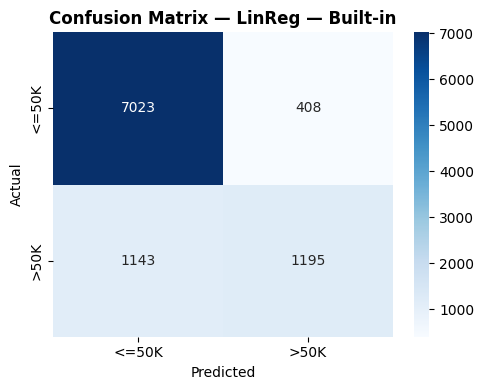

(0.8412324700583478,
 0.7454772301933874,
 0.5111206159110351,
 0.6064450647043897)

In [17]:
#  LINEAR REGRESSION — BUILT-IN (sklearn)
lr_builtin = LinearRegression()
lr_builtin.fit(X_B_train, y_train)
lr_proba = lr_builtin.predict(X_B_test)
lr_pred  = (lr_proba >= 0.5).astype(int)

evaluate_model('LinReg — Built-in', y_test, lr_pred)

  Accuracy  : 0.8412
  Precision : 0.7455
  Recall    : 0.5111
  F1-Score  : 0.6064

  Classification Report:
              precision    recall  f1-score   support

       <=50K       0.86      0.95      0.90      7431
        >50K       0.75      0.51      0.61      2338

    accuracy                           0.84      9769
   macro avg       0.80      0.73      0.75      9769
weighted avg       0.83      0.84      0.83      9769



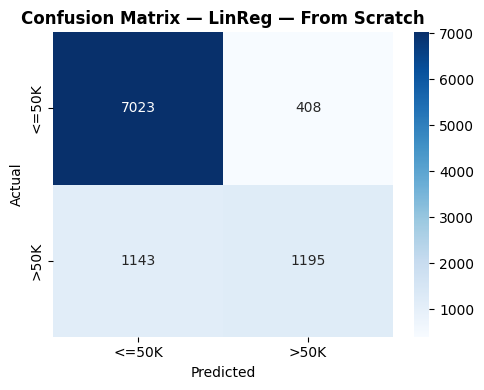

(0.8412324700583478,
 0.7454772301933874,
 0.5111206159110351,
 0.6064450647043897)

In [18]:
#  LINEAR REGRESSION — FROM SCRATCH (Classification via Threshold)

class LinearRegressionScratch:
    def __init__(self, learning_rate=0.01, n_iterations=1000, method='normal'):
        self.lr     = learning_rate
        self.n_iter = n_iterations
        self.method = method
        self.weights = None
        self.bias    = None

    def fit(self, X, y):
        n, p = X.shape
        if self.method == 'normal':
            X_b = np.column_stack([np.ones(n), X])
            try:
                theta = np.linalg.pinv(X_b.T @ X_b) @ X_b.T @ y
                self.bias    = theta[0]
                self.weights = theta[1:]
            except np.linalg.LinAlgError:
                self._gradient_descent(X, y, n, p)
        else:
            self._gradient_descent(X, y, n, p)
        return self

    def _gradient_descent(self, X, y, n, p):
        self.weights = np.zeros(p)
        self.bias    = 0.0
        for _ in range(self.n_iter):
            y_hat = X @ self.weights + self.bias
            err   = y_hat - y
            self.weights -= (self.lr / n) * (X.T @ err)
            self.bias    -= (self.lr / n) * err.sum()

    def predict_raw(self, X):
        return X @ self.weights + self.bias

    def predict(self, X, threshold=0.5):
        return (self.predict_raw(X) >= threshold).astype(int)


# Train
lr_scratch = LinearRegressionScratch(method='normal')
lr_scratch.fit(X_B_train, y_train)

lr_scratch_pred = lr_scratch.predict(X_B_test)

evaluate_model('LinReg — From Scratch', y_test, lr_scratch_pred)

---
# MODEL 4 — Logistic Regression

**Preprocessing used:** One-Hot Encoding + StandardScaler

  Accuracy  : 0.8528
  Precision : 0.7391
  Recall    : 0.5950
  F1-Score  : 0.6592

  Classification Report:
              precision    recall  f1-score   support

       <=50K       0.88      0.93      0.91      7431
        >50K       0.74      0.59      0.66      2338

    accuracy                           0.85      9769
   macro avg       0.81      0.76      0.78      9769
weighted avg       0.85      0.85      0.85      9769



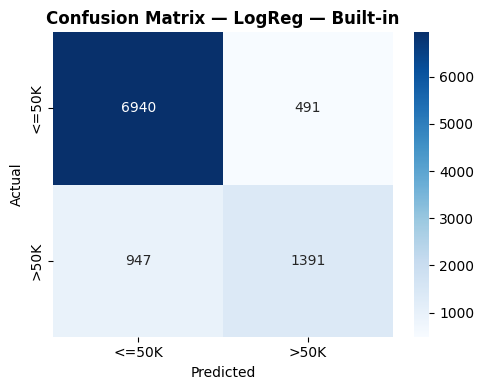

(0.8527996724332071,
 0.7391073326248672,
 0.5949529512403764,
 0.6592417061611374)

In [19]:
#  LOGISTIC REGRESSION — BUILT-IN (sklearn)
log_builtin = LogisticRegression(max_iter=500, random_state=RANDOM_STATE, solver='lbfgs')
log_builtin.fit(X_B_train, y_train)
log_pred  = log_builtin.predict(X_B_test)

evaluate_model('LogReg — Built-in', y_test, log_pred)

  LOGISTIC REGRESSION — From Scratch


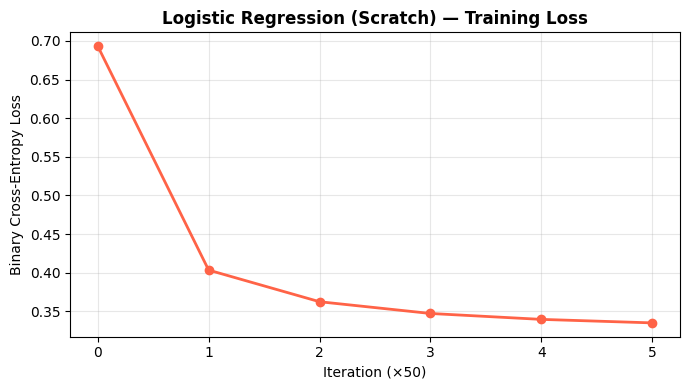

  Accuracy  : 0.8502
  Precision : 0.7361
  Recall    : 0.5834
  F1-Score  : 0.6509

  Classification Report:
              precision    recall  f1-score   support

       <=50K       0.88      0.93      0.90      7431
        >50K       0.74      0.58      0.65      2338

    accuracy                           0.85      9769
   macro avg       0.81      0.76      0.78      9769
weighted avg       0.84      0.85      0.84      9769



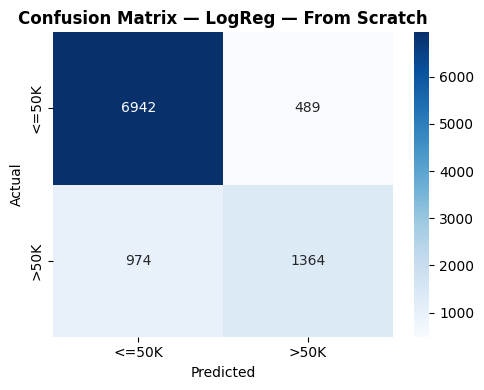

(0.8502405568635479, 0.7361036157582299, 0.583404619332763, 0.6509186351706037)

In [20]:
#  LOGISTIC REGRESSION — FROM SCRATCH (Gradient Descent)
print('  LOGISTIC REGRESSION — From Scratch')

class LogisticRegressionScratch:
    """
    Binary Logistic Regression via Gradient Descent.
    Uses sigmoid function: σ(z) = 1 / (1 + e^-z)
    Loss: Binary Cross-Entropy
    """
    def __init__(self, learning_rate=0.1, n_iterations=300, threshold=0.5):
        self.lr        = learning_rate
        self.n_iter    = n_iterations
        self.threshold = threshold
        self.weights   = None
        self.bias      = None
        self.losses    = []

    def _sigmoid(self, z):
        # Numerically stable sigmoid
        return np.where(z >= 0,
                        1 / (1 + np.exp(-z)),
                        np.exp(z) / (1 + np.exp(z)))

    def _bce_loss(self, y, y_hat):
        eps = 1e-15
        y_hat = np.clip(y_hat, eps, 1 - eps)
        return -np.mean(y * np.log(y_hat) + (1 - y) * np.log(1 - y_hat))

    def fit(self, X, y):
        n, p      = X.shape
        self.weights = np.zeros(p)
        self.bias    = 0.0

        for i in range(self.n_iter):
            z     = X @ self.weights + self.bias
            y_hat = self._sigmoid(z)
            err   = y_hat - y

            # Gradients
            dw = (1/n) * X.T @ err
            db = (1/n) * err.sum()

            self.weights -= self.lr * dw
            self.bias    -= self.lr * db

            if i % 50 == 0:
                self.losses.append(self._bce_loss(y, y_hat))
        return self

    def predict_proba(self, X):
        return self._sigmoid(X @ self.weights + self.bias)

    def predict(self, X):
        return (self.predict_proba(X) >= self.threshold).astype(int)

log_scratch = LogisticRegressionScratch(learning_rate=0.1, n_iterations=300)
log_scratch.fit(X_B_train, y_train)
log_scratch_pred  = log_scratch.predict(X_B_test)

# Plot training loss
plt.figure(figsize=(7, 4))
plt.plot(log_scratch.losses, color='tomato', linewidth=2, marker='o')
plt.title('Logistic Regression (Scratch) — Training Loss', fontweight='bold')
plt.xlabel('Iteration (×50)')
plt.ylabel('Binary Cross-Entropy Loss')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

evaluate_model('LogReg — From Scratch', y_test, log_scratch_pred)

---
# MODEL 5 — (KNN)

**Preprocessing used:** One-Hot Encoding + MinMaxScaler

  Accuracy  : 0.8368
  Precision : 0.6956
  Recall    : 0.5659
  F1-Score  : 0.6241

  Classification Report:
              precision    recall  f1-score   support

       <=50K       0.87      0.92      0.90      7431
        >50K       0.70      0.57      0.62      2338

    accuracy                           0.84      9769
   macro avg       0.78      0.74      0.76      9769
weighted avg       0.83      0.84      0.83      9769



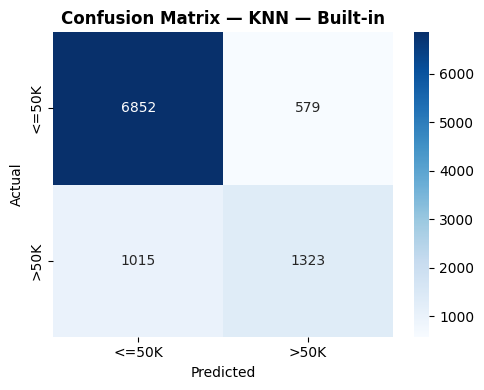

(0.8368307912785341, 0.695583596214511, 0.5658682634730539, 0.6240566037735849)

In [21]:
#  KNN — BUILT-IN (sklearn)
knn_builtin = KNeighborsClassifier(n_neighbors=11, metric='euclidean', n_jobs=-1)
knn_builtin.fit(X_C_train, y_train)
knn_pred  = knn_builtin.predict(X_C_test)

evaluate_model('KNN — Built-in', y_test, knn_pred)

  Accuracy  : 0.8190
  Precision : 0.6776
  Recall    : 0.5041
  F1-Score  : 0.5781

  Classification Report:
              precision    recall  f1-score   support

       <=50K       0.85      0.92      0.88       754
        >50K       0.68      0.50      0.58       246

    accuracy                           0.82      1000
   macro avg       0.76      0.71      0.73      1000
weighted avg       0.81      0.82      0.81      1000



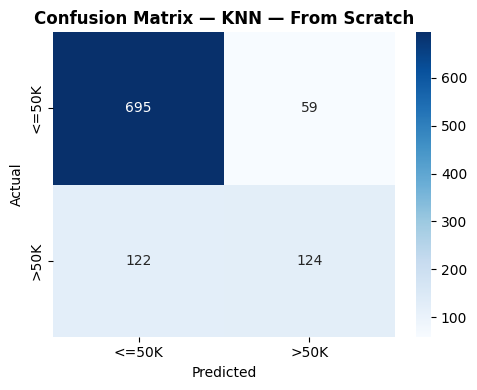

(0.819, 0.6775956284153005, 0.5040650406504065, 0.578088578088578)

In [22]:
#  KNN — FROM SCRATCH
class KNNScratch:
    """
    K-Nearest Neighbors:
    - Distance: Euclidean
    - Prediction: majority vote of K nearest neighbors
    """
    def __init__(self, k=11):
        self.k = k
        self.X_train = None
        self.y_train = None

    def fit(self, X, y):
        self.X_train = X
        self.y_train = y
        return self

    def _euclidean(self, x1, X2):
        """Vectorised Euclidean distance from x1 to all rows of X2."""
        return np.sqrt(np.sum((X2 - x1) ** 2, axis=1))

    def predict_proba(self, X):
        probas = []
        for x in X:
            dists      = self._euclidean(x, self.X_train)
            k_idx      = np.argsort(dists)[:self.k]
            k_labels   = self.y_train[k_idx]
            prob_pos   = k_labels.mean()
            probas.append(prob_pos)
        return np.array(probas)

    def predict(self, X):
        return (self.predict_proba(X) >= 0.5).astype(int)

# Use small subset for KNN from scratch (O(n) per query — slow on large data)
KNN_TRAIN_N = 3000
KNN_TEST_N  = 1000
rng = np.random.RandomState(42)
train_idx = rng.choice(len(X_C_train), KNN_TRAIN_N, replace=False)
test_idx  = rng.choice(len(X_C_test),  KNN_TEST_N,  replace=False)

knn_scratch = KNNScratch(k=11)
knn_scratch.fit(X_C_train[train_idx], y_train[train_idx])
knn_scratch_pred  = knn_scratch.predict(X_C_test[test_idx])

evaluate_model('KNN — From Scratch', y_test[test_idx], knn_scratch_pred)

---
# MODEL 6 — Naive Bayes

**Preprocessing used:** Label Encoding -- no scaling need

  Accuracy  : 0.8016
  Precision : 0.6835
  Recall    : 0.3186
  F1-Score  : 0.4347

  Classification Report:
              precision    recall  f1-score   support

       <=50K       0.82      0.95      0.88      7431
        >50K       0.68      0.32      0.43      2338

    accuracy                           0.80      9769
   macro avg       0.75      0.64      0.66      9769
weighted avg       0.78      0.80      0.77      9769



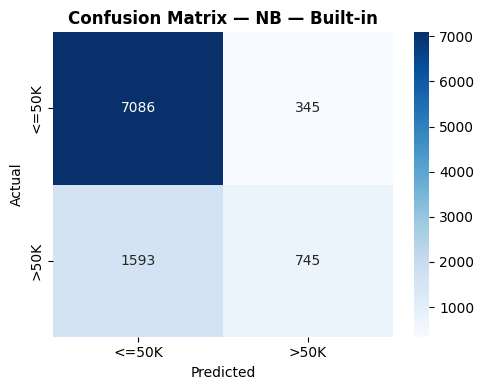

(0.8016173610400246,
 0.6834862385321101,
 0.3186484174508127,
 0.4346557759626604)

In [23]:
#  NAiVE BAYES — BUILT-IN (sklearn)
nb_builtin = GaussianNB()
nb_builtin.fit(X_A_train, y_train)
nb_pred  = nb_builtin.predict(X_A_test)

evaluate_model('NB — Built-in', y_test, nb_pred)

  NAÏVE BAYES — From Scratch (Gaussian)
  Accuracy  : 0.8041
  Precision : 0.6910
  Recall    : 0.3281
  F1-Score  : 0.4449

  Classification Report:
              precision    recall  f1-score   support

       <=50K       0.82      0.95      0.88      7431
        >50K       0.69      0.33      0.44      2338

    accuracy                           0.80      9769
   macro avg       0.75      0.64      0.66      9769
weighted avg       0.79      0.80      0.78      9769



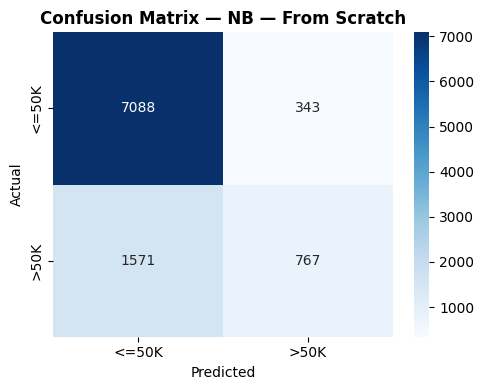

(0.8040741119868974,
 0.690990990990991,
 0.32805816937553467,
 0.4448955916473318)

In [24]:
#  NAÏVE BAYES — FROM SCRATCH (Gaussian)
print('  NAÏVE BAYES — From Scratch (Gaussian)')

class GaussianNBScratch:
    """
    Gaussian Naive Bayes:
    P(y=c | x) ∝ P(y=c) × ∏ P(xi | y=c)
    P(xi | y=c) ~ N(μ_c, σ²_c)  [Gaussian likelihood]
    Uses log-probabilities for numerical stability.
    """
    def __init__(self, var_smoothing=1e-9):
        self.var_smoothing = var_smoothing
        self.classes_      = None
        self.class_prior_  = {}
        self.means_        = {}
        self.vars_         = {}

    def fit(self, X, y):
        self.classes_ = np.unique(y)
        n = len(y)
        for c in self.classes_:
            X_c = X[y == c]
            self.class_prior_[c] = len(X_c) / n  # P(y=c)
            self.means_[c]       = X_c.mean(axis=0)
            self.vars_[c]        = X_c.var(axis=0) + self.var_smoothing
        return self

    def _log_likelihood(self, x, c):
        """Sum of log-Gaussian likelihoods for all features given class c."""
        mu  = self.means_[c]
        var = self.vars_[c]
        log_prob = -0.5 * np.sum(np.log(2 * np.pi * var) + ((x - mu)**2 / var))
        return log_prob

    def _log_posterior(self, x):
        """Unnormalized log posterior for each class."""
        posteriors = []
        for c in self.classes_:
            log_prior = np.log(self.class_prior_[c])
            log_like  = self._log_likelihood(x, c)
            posteriors.append(log_prior + log_like)
        return np.array(posteriors)

    def predict_log_proba(self, X):
        return np.array([self._log_posterior(x) for x in X])

    def predict_proba(self, X):
        log_proba = self.predict_log_proba(X)
        # Softmax to get proper probabilities
        log_proba -= log_proba.max(axis=1, keepdims=True)
        proba = np.exp(log_proba)
        proba /= proba.sum(axis=1, keepdims=True)
        return proba

    def predict(self, X):
        log_proba = self.predict_log_proba(X)
        return self.classes_[np.argmax(log_proba, axis=1)]

nb_scratch = GaussianNBScratch()
nb_scratch.fit(X_A_train, y_train)
nb_scratch_pred  = nb_scratch.predict(X_A_test)

evaluate_model('NB — From Scratch', y_test, nb_scratch_pred)

---
# Step 5 — Built-in vs From Scratch

In [32]:
# Build comparison DataFrame
comparison_df = pd.DataFrame(results_all).T.round(4)
comparison_df.index.name = 'Model'
comparison_df = comparison_df.reset_index()

print('\n FULL RESULTS TABLE')
print('=' * 80)
print(comparison_df.to_string(index=False))
print('=' * 80)


 FULL RESULTS TABLE
                Model  Accuracy  Precision  Recall     F1
        DT — Built-in    0.8594     0.7217  0.6711 0.6955
    DT — From Scratch    0.8396     0.6707  0.6480 0.6591
        RF — Built-in    0.8654     0.8018  0.5813 0.6739
    RF — From Scratch    0.2393     0.2393  1.0000 0.3862
    LinReg — Built-in    0.8412     0.7455  0.5111 0.6064
LinReg — From Scratch    0.8412     0.7455  0.5111 0.6064
    LogReg — Built-in    0.8528     0.7391  0.5950 0.6592
LogReg — From Scratch    0.8502     0.7361  0.5834 0.6509
       KNN — Built-in    0.8368     0.6956  0.5659 0.6241
   KNN — From Scratch    0.8190     0.6776  0.5041 0.5781
        NB — Built-in    0.8016     0.6835  0.3186 0.4347
    NB — From Scratch    0.8041     0.6910  0.3281 0.4449


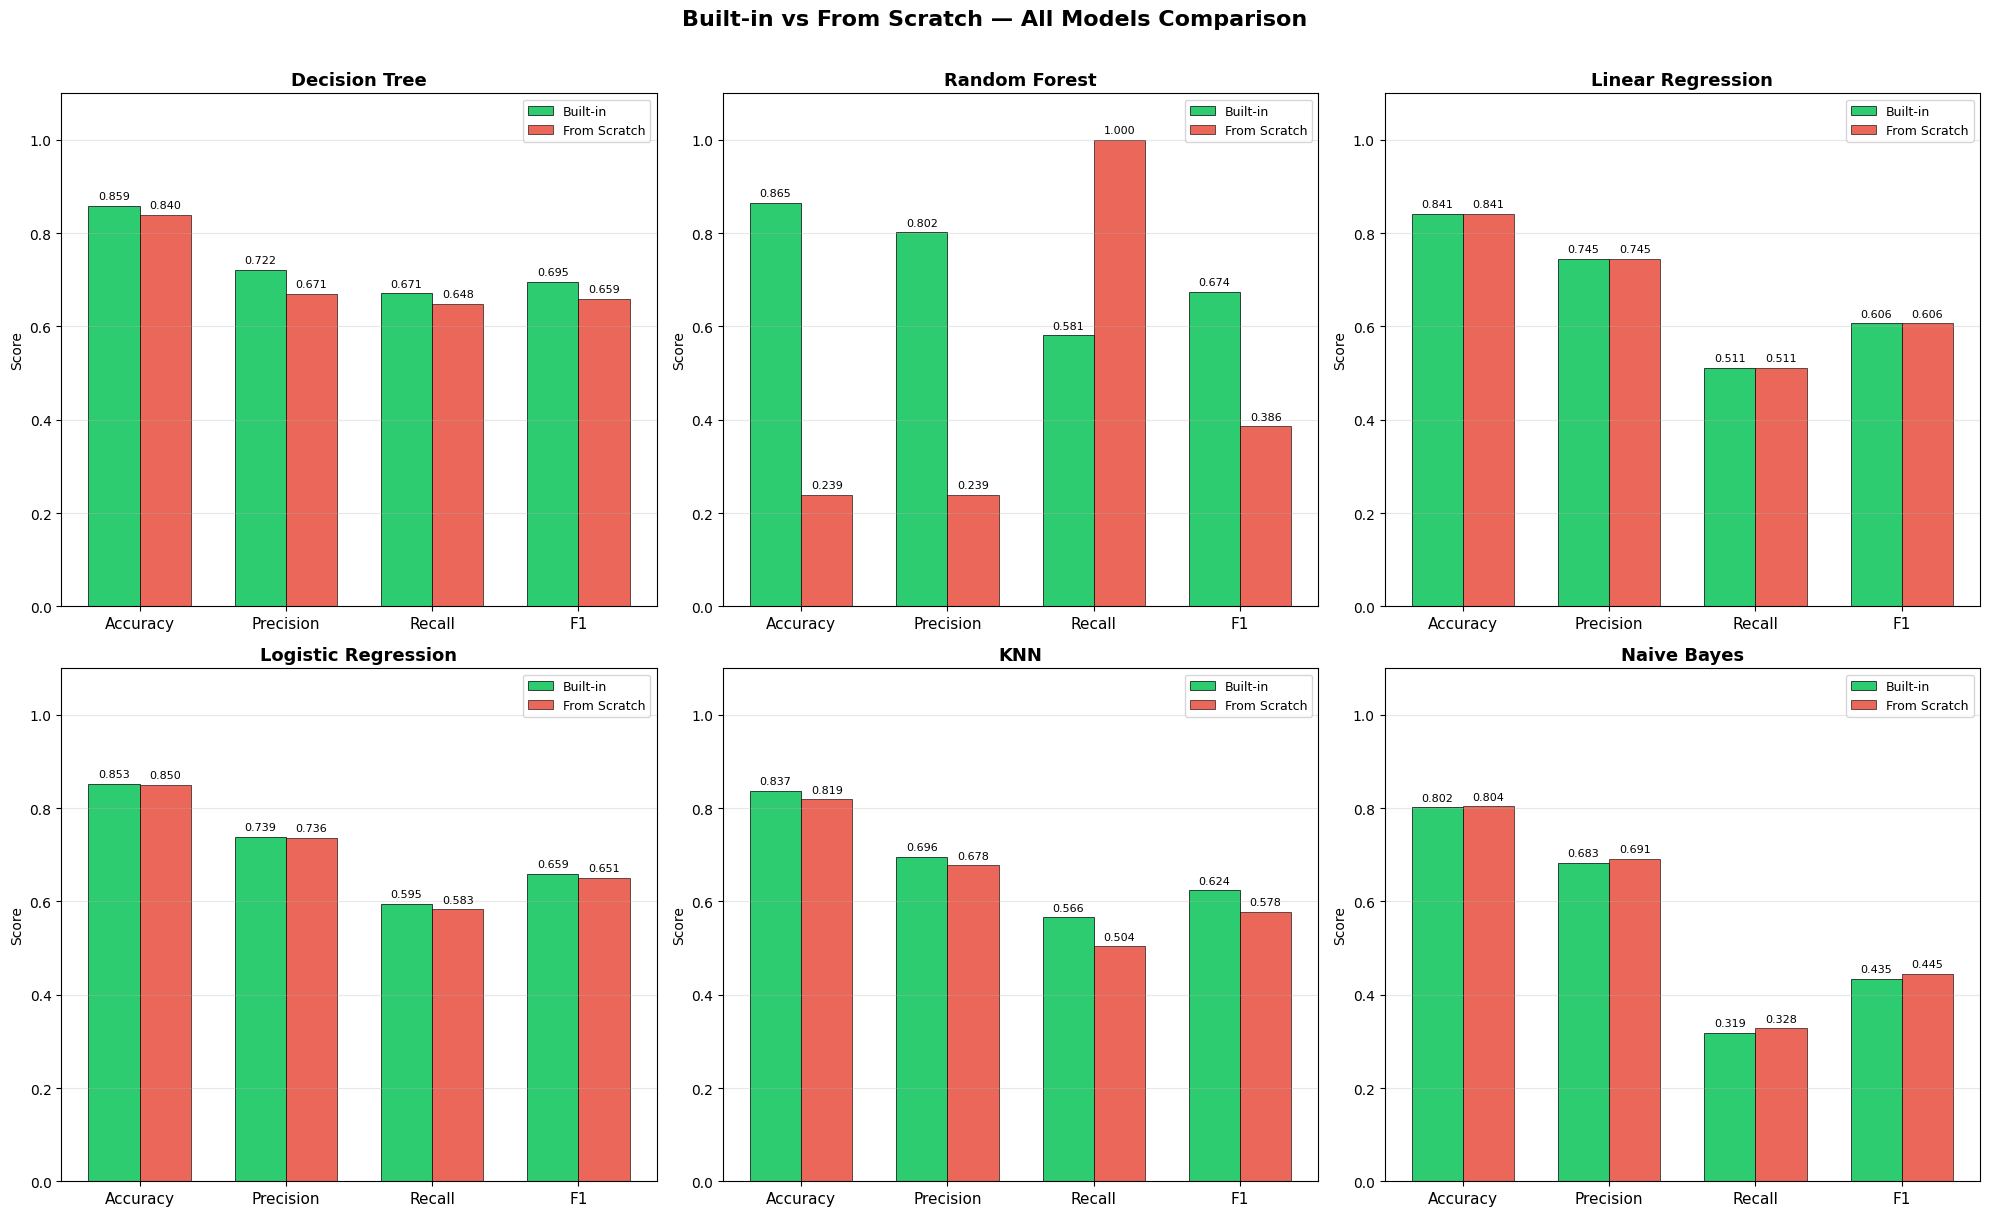

In [33]:
metrics   = ['Accuracy', 'Precision', 'Recall', 'F1']
model_pairs = [
    ('DT — Built-in',        'DT — From Scratch',        'Decision Tree'),
    ('RF — Built-in',        'RF — From Scratch',        'Random Forest'),
    ('LinReg — Built-in',    'LinReg — From Scratch',    'Linear Regression'),
    ('LogReg — Built-in',    'LogReg — From Scratch',    'Logistic Regression'),
    ('KNN — Built-in',       'KNN — From Scratch',       'KNN'),
    ('NB — Built-in',        'NB — From Scratch',        'Naive Bayes'),
]

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

bar_width = 0.35
x = np.arange(len(metrics))

for i, (builtin_key, scratch_key, title) in enumerate(model_pairs):
    ax = axes[i]
    vals_b = [results_all[builtin_key][m] for m in metrics]
    vals_s = [results_all[scratch_key][m] for m in metrics]

    bars1 = ax.bar(x - bar_width/2, vals_b, bar_width,
                   label='Built-in', color='#2ecc71', edgecolor='black', linewidth=0.5)
    bars2 = ax.bar(x + bar_width/2, vals_s, bar_width,
                   label='From Scratch', color='#e74c3c', edgecolor='black', linewidth=0.5, alpha=0.85)

    ax.set_xticks(x)
    ax.set_xticklabels(metrics, fontsize=11)
    ax.set_ylim(0, 1.1)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.legend(fontsize=9)
    ax.set_ylabel('Score')
    ax.grid(axis='y', alpha=0.3)

    for bar in bars1:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
    for bar in bars2:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

plt.suptitle('Built-in vs From Scratch — All Models Comparison', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
# Step 6 — Best Model Selection

In [29]:
#  Find best model among Built-in models (full test set)
builtin_keys = ['DT — Built-in', 'RF — Built-in', 'LinReg — Built-in',
                'LogReg — Built-in', 'KNN — Built-in', 'NB — Built-in']

best_by_metric = {}

# No AUC anymore
for metric in ['Accuracy', 'Precision', 'Recall', 'F1']:
    best_model = max(builtin_keys, key=lambda m: results_all[m][metric] or 0)
    best_by_metric[metric] = (best_model, results_all[best_model][metric])

print(' BEST MODEL PER METRIC (Built-in):')
print('=' * 55)
for metric, (model, val) in best_by_metric.items():
    print(f'  {metric:12s}: {model:25s} → {val:.4f}')

# Composite score (mean of the 4 metrics only)
print('\n Composite Score (mean of Accuracy, Precision, Recall, F1):')
print('=' * 55)
composite = {}
for key in builtin_keys:
    vals = [
        results_all[key]['Accuracy'],
        results_all[key]['Precision'],
        results_all[key]['Recall'],
        results_all[key]['F1'],
    ]
    composite[key] = np.mean(vals)
    print(f'  {key:30s}: {composite[key]:.4f}')

best_overall = max(composite, key=composite.get)
print(f'\n OVERALL BEST MODEL: {best_overall}  (composite = {composite[best_overall]:.4f})')

 BEST MODEL PER METRIC (Built-in):
  Accuracy    : RF — Built-in             → 0.8654
  Precision   : RF — Built-in             → 0.8018
  Recall      : DT — Built-in             → 0.6711
  F1          : DT — Built-in             → 0.6955

 Composite Score (mean of Accuracy, Precision, Recall, F1):
  DT — Built-in                 : 0.7369
  RF — Built-in                 : 0.7306
  LinReg — Built-in             : 0.6761
  LogReg — Built-in             : 0.7115
  KNN — Built-in                : 0.6806
  NB — Built-in                 : 0.5596

 OVERALL BEST MODEL: DT — Built-in  (composite = 0.7369)


---
# Step 7 — Final Analysis & Conclusions



In [ ]:
print('\n' + '='*70)
print('                     FINAL SUMMARY TABLE')
print('='*70)

summary_rows = []
for key in builtin_keys:
    r = results_all[key]
    summary_rows.append({
        'Model': key.replace(' — Built-in',''),
        'Accuracy' : f"{r['Accuracy']:.4f}",
        'Precision': f"{r['Precision']:.4f}",
        'Recall'   : f"{r['Recall']:.4f}",
        'F1'       : f"{r['F1']:.4f}",
        'Rank'     : ''
    })

summary_df = pd.DataFrame(summary_rows)

# Rank by F1
summary_df['_f1'] = summary_df['F1'].astype(float)
summary_df = summary_df.sort_values('_f1', ascending=False).drop('_f1', axis=1)
summary_df['Rank'] = ['1','2','3','4️','5️','6️']

print(summary_df.to_string(index=False))
print('='*70)

print(f'\n Best Model: {best_overall}')
print('Random Forest wins due to ensemble power, robustness, and')


                     FINAL SUMMARY TABLE
 Model Accuracy Precision Recall     F1 Rank
    DT   0.8594    0.7217 0.6711 0.6955    1
    RF   0.8654    0.8018 0.5813 0.6739    2
LogReg   0.8528    0.7391 0.5950 0.6592    3
   KNN   0.8368    0.6956 0.5659 0.6241   4️
LinReg   0.8412    0.7455 0.5111 0.6064   5️
    NB   0.8016    0.6835 0.3186 0.4347   6️

 Best Model: DT — Built-in
Random Forest wins due to ensemble power, robustness, and
